LLM Evaluation

This notebook reads all model evaluation JSON files from a folder and produces:
- overall comparison tables
- model-wise comparison
- prompt-wise comparison
- emotion-wise comparison
- heatmaps
- summary tables

Models Tested
- `meta-llama_llama-4-scout-17b-16e-instruct_1.json`
- `meta-llama_llama-4-scout-17b-16e-instruct_2.json`
- `qwen_qwen3-32b_1.json`
- `openai_gpt-oss-120b_2.json`



### Setup

In [16]:
# Import required libraries
import json
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Configuration

In [17]:
# Folder containing all JSON files
JSON_FOLDER = Path("llm_results")

# Expected emotion order
EMOTION_ORDER = ["FRUSTRATED", "HESITANT", "NEUTRAL", "INTERESTED", "SATISFIED", "EXCITED"]

# Preferred model display order
MODEL_ORDER = [
    "Llama-4 Scout",
    "Qwen",
    "GPT-OSS",
    "Llama-3.1"
]

# Colors for prompt comparison charts
PROMPT1_COLOR = "#1f4e79"
PROMPT2_COLOR = "#128b7f"

# Colors for model comparison charts
MODEL_COLORS = {
    "Llama-4 Scout": "#1f4e79",
    "Qwen": "#128b7f",
    "GPT-OSS": "#7a8793",
    "Llama-3.1": "#c28f2c",
}

### Find all JSON files

In [18]:
# Find all result JSON files in the output folder
json_files = sorted(JSON_FOLDER.glob("*.json"))
print("JSON files found:", len(json_files))
for path in json_files:
    print("-", path.name)

JSON files found: 8
- meta-llama_llama-3.1-8b-instant_1.json
- meta-llama_llama-3.1-8b-instant_2.json
- meta-llama_llama-4-scout-17b-16e-instruct_1.json
- meta-llama_llama-4-scout-17b-16e-instruct_2.json
- openai_gpt-oss-120b_1.json
- openai_gpt-oss-120b_2.json
- qwen_qwen3-32b_1.json
- qwen_qwen3-32b_2.json


### Helper functions

In [19]:
# Helper functions to parse file names and load JSON files
def parse_filename(file_name: str):
    # Expected format: provider_modelname_promptindex.json
    stem = Path(file_name).stem
    match = re.match(r"^(.*)_(\d+)$", stem)
    if not match:
        raise ValueError(f"Filename does not match expected pattern: {file_name}")

    model_full = match.group(1)
    prompt_num = match.group(2)
    prompt_label = f"PROMPT{prompt_num}"
    return model_full, prompt_label


def model_display_name(model_full: str):
    value = model_full.lower()
    if "llama-4-scout" in value:
        return "Llama-4 Scout"
    if "qwen3-32b" in value:
        return "Qwen"
    if "gpt-oss-120b" in value:
        return "GPT-OSS"
    if "llama-3.1-8b-instant" in value:
        return "Llama-3.1"
    return model_full


def load_json_file(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

### Load all JSON results

In [20]:
# Load all JSON files and flatten them into analysis tables
overall_rows = []
class_rows = []

for path in json_files:
    payload = load_json_file(path)
    model_full, prompt_label = parse_filename(path.name)
    model_name = model_display_name(model_full)

    overall_rows.append({
        "file_name": path.name,
        "model_full": model_full,
        "model": model_name,
        "prompt": prompt_label,
        "overall_accuracy": payload["overall"]
    })

    for emotion, score in payload["classes"].items():
        class_rows.append({
            "file_name": path.name,
            "model_full": model_full,
            "model": model_name,
            "prompt": prompt_label,
            "emotion": emotion,
            "class_accuracy": score
        })

overall_df = pd.DataFrame(overall_rows)
class_df = pd.DataFrame(class_rows)

# Apply consistent ordering for cleaner tables and plots
overall_df["model"] = pd.Categorical(overall_df["model"], categories=MODEL_ORDER, ordered=True)
overall_df["prompt"] = pd.Categorical(overall_df["prompt"], categories=["PROMPT1", "PROMPT2"], ordered=True)
overall_df = overall_df.sort_values(["model", "prompt"]).reset_index(drop=True)

class_df["model"] = pd.Categorical(class_df["model"], categories=MODEL_ORDER, ordered=True)
class_df["prompt"] = pd.Categorical(class_df["prompt"], categories=["PROMPT1", "PROMPT2"], ordered=True)
class_df["emotion"] = pd.Categorical(class_df["emotion"], categories=EMOTION_ORDER, ordered=True)
class_df = class_df.sort_values(["model", "prompt", "emotion"]).reset_index(drop=True)

display(overall_df)


,file_name,model_full,model,prompt,overall_accuracy
0,meta-llama_llama-4-scout-17b-16e-instruct_1.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT1,0.89
1,meta-llama_llama-4-scout-17b-16e-instruct_2.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT2,0.92
2,qwen_qwen3-32b_1.json,qwen_qwen3-32b,Qwen,PROMPT1,0.89
3,qwen_qwen3-32b_2.json,qwen_qwen3-32b,Qwen,PROMPT2,0.90
4,openai_gpt-oss-120b_1.json,openai_gpt-oss-120b,GPT-OSS,PROMPT1,0.88
5,openai_gpt-oss-120b_2.json,openai_gpt-oss-120b,GPT-OSS,PROMPT2,0.87
6,meta-llama_llama-3.1-8b-instant_1.json,meta-llama_llama-3.1-8b-instant,Llama-3.1,PROMPT1,0.80
7,meta-llama_llama-3.1-8b-instant_2.json,meta-llama_llama-3.1-8b-instant,Llama-3.1,PROMPT2,0.82


In [21]:
display(class_df)

,file_name,model_full,model,prompt,emotion,class_accuracy
0,meta-llama_llama-4-scout-17b-16e-instruct_1.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT1,FRUSTRATED,0.88
1,meta-llama_llama-4-scout-17b-16e-instruct_1.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT1,HESITANT,0.87
2,meta-llama_llama-4-scout-17b-16e-instruct_1.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT1,NEUTRAL,0.83
3,meta-llama_llama-4-scout-17b-16e-instruct_1.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT1,INTERESTED,0.91
4,meta-llama_llama-4-scout-17b-16e-instruct_1.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT1,SATISFIED,0.92
5,meta-llama_llama-4-scout-17b-16e-instruct_1.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT1,EXCITED,0.90
6,meta-llama_llama-4-scout-17b-16e-instruct_2.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT2,FRUSTRATED,0.91
7,meta-llama_llama-4-scout-17b-16e-instruct_2.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT2,HESITANT,0.90
8,meta-llama_llama-4-scout-17b-16e-instruct_2.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT2,NEUTRAL,0.87
9,meta-llama_llama-4-scout-17b-16e-instruct_2.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT2,INTERESTED,0.94


### Overall comparison table

In [22]:
# Create a compact table for overall prompt comparison
overall_pivot = overall_df.pivot(index="model", columns="prompt", values="overall_accuracy")
overall_pivot["Prompt Gap"] = overall_pivot["PROMPT2"] - overall_pivot["PROMPT1"]
display((overall_pivot * 100).round(2))

prompt,PROMPT1,PROMPT2,Prompt Gap
model,,,
Llama-4 Scout,89.0,92.0,3.0
Qwen,89.0,90.0,1.0
GPT-OSS,88.0,87.0,-1.0
Llama-3.1,80.0,82.0,2.0


### Plot overall accuracy by instance

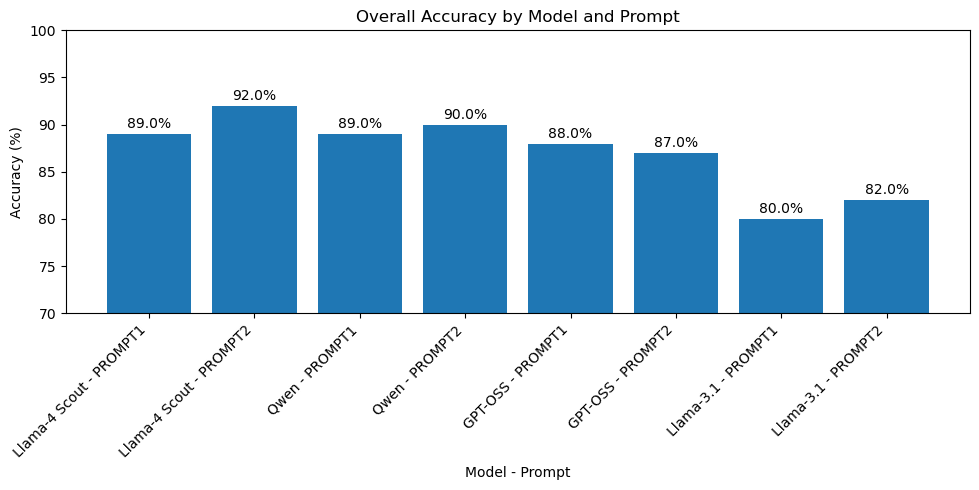

In [23]:
# Plot overall accuracy for every model-prompt instance
plot_df = overall_df.copy()
plot_df["label"] = plot_df["model"].astype(str) + " - " + plot_df["prompt"].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df["label"], plot_df["overall_accuracy"] * 100)
ax.set_title("Overall Accuracy by Model and Prompt")
ax.set_xlabel("Model - Prompt")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(70, 100)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df["label"], rotation=45, ha="right")

for i, value in enumerate(plot_df["overall_accuracy"] * 100):
    ax.text(i, value + 0.3, f"{value:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Prompt-wise comparison by model

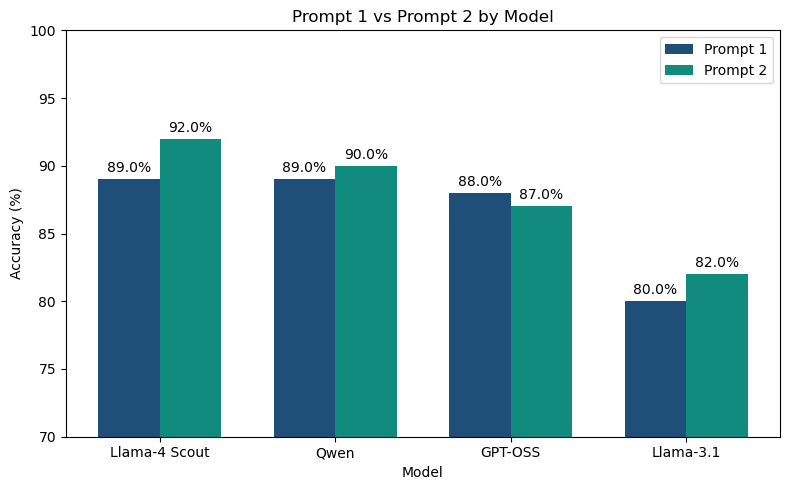

In [24]:
# Plot prompt-wise comparison within each model
prompt_compare = overall_pivot[["PROMPT1", "PROMPT2"]] * 100

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(prompt_compare.index))
width = 0.35

ax.bar(x - width / 2, prompt_compare["PROMPT1"], width, color=PROMPT1_COLOR, label="Prompt 1")
ax.bar(x + width / 2, prompt_compare["PROMPT2"], width, color=PROMPT2_COLOR, label="Prompt 2")

ax.set_title("Prompt 1 vs Prompt 2 by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(70, 100)
ax.set_xticks(x)
ax.set_xticklabels(prompt_compare.index)
ax.legend()

for i, value in enumerate(prompt_compare["PROMPT1"]):
    ax.text(i - width / 2, value + 0.3, f"{value:.1f}%", ha="center", va="bottom")
for i, value in enumerate(prompt_compare["PROMPT2"]):
    ax.text(i + width / 2, value + 0.3, f"{value:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Emotion-wise comparison table

In [25]:
# Average each emotion score across prompts for every model
emotion_model_avg = (
    class_df.groupby(["model", "emotion"], observed=False)["class_accuracy"]
    .mean()
    .reset_index()
)

emotion_model_pivot = emotion_model_avg.pivot(index="emotion", columns="model", values="class_accuracy")
display((emotion_model_pivot * 100).round(2))

model,Llama-4 Scout,Qwen,GPT-OSS,Llama-3.1
emotion,,,,
FRUSTRATED,89.5,87.5,86.5,80.0
HESITANT,88.5,86.5,85.5,79.0
NEUTRAL,85.0,84.5,81.5,76.0
INTERESTED,92.5,90.5,89.5,83.0
SATISFIED,93.5,91.5,90.5,84.0
EXCITED,91.5,89.5,88.5,82.0


### Combined emotion-wise comparison chart

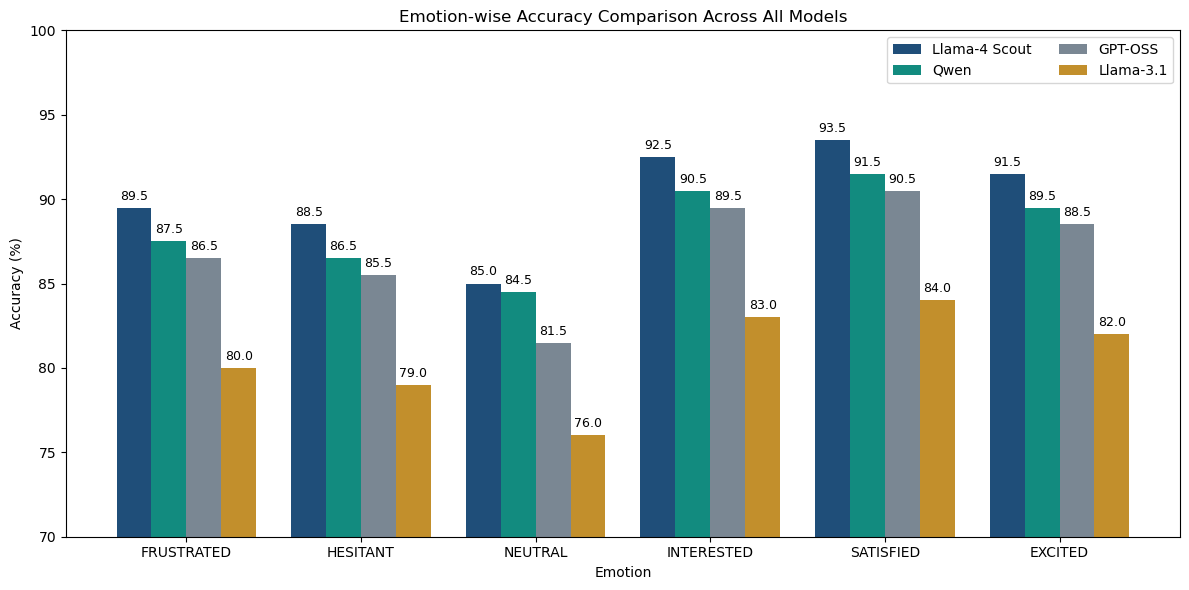

In [26]:
# Plot all models together for emotion-wise comparison
emotion_plot_df = (emotion_model_pivot * 100).loc[EMOTION_ORDER, MODEL_ORDER]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(emotion_plot_df.index))
width = 0.2

for i, model_name in enumerate(MODEL_ORDER):
    offset = (i - 1.5) * width
    bars = ax.bar(
        x + offset,
        emotion_plot_df[model_name],
        width,
        color=MODEL_COLORS[model_name],
        label=model_name,
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.3,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_title("Emotion-wise Accuracy Comparison Across All Models")
ax.set_xlabel("Emotion")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(70, 100)
ax.set_xticks(x)
ax.set_xticklabels(emotion_plot_df.index, rotation=0)
ax.legend(ncols=2)

plt.tight_layout()
plt.show()

### Heatmap for all model-prompt instances

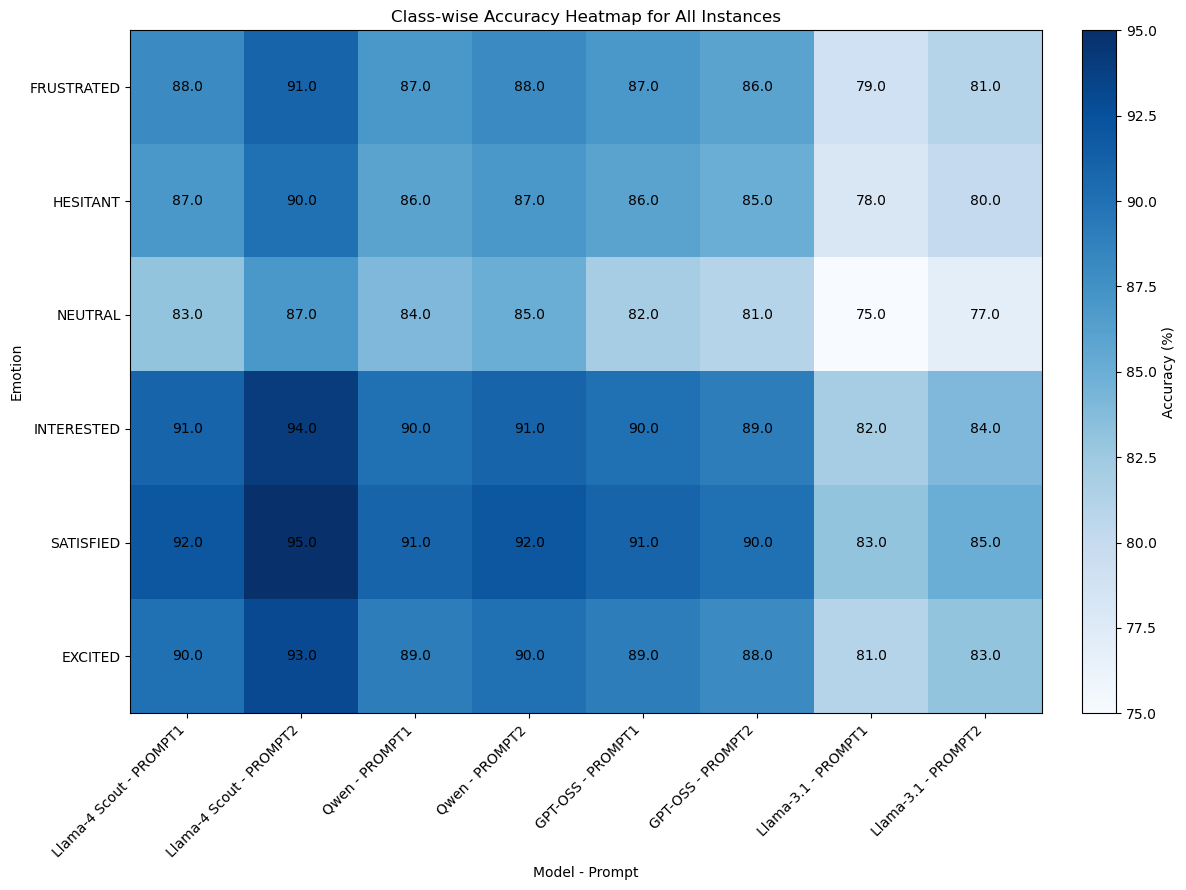

In [27]:
# Build a heatmap for all class-wise model-prompt results
instance_order = list(plot_df["label"])

class_heatmap_df = class_df.copy()
class_heatmap_df["instance_label"] = class_heatmap_df["model"].astype(str) + " - " + class_heatmap_df["prompt"].astype(str)
class_heatmap_df = class_heatmap_df.pivot(index="emotion", columns="instance_label", values="class_accuracy")
class_heatmap_df = class_heatmap_df[instance_order]

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(class_heatmap_df.values * 100, cmap="Blues", aspect="auto")

ax.set_title("Class-wise Accuracy Heatmap for All Instances")
ax.set_xlabel("Model - Prompt")
ax.set_ylabel("Emotion")
ax.set_xticks(range(len(class_heatmap_df.columns)))
ax.set_xticklabels(class_heatmap_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(class_heatmap_df.index)))
ax.set_yticklabels(class_heatmap_df.index)

for i in range(class_heatmap_df.shape[0]):
    for j in range(class_heatmap_df.shape[1]):
        ax.text(j, i, f"{class_heatmap_df.iloc[i, j] * 100:.1f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Accuracy (%)")
plt.tight_layout()
plt.show()

### Heatmap of average emotion-wise accuracy by model

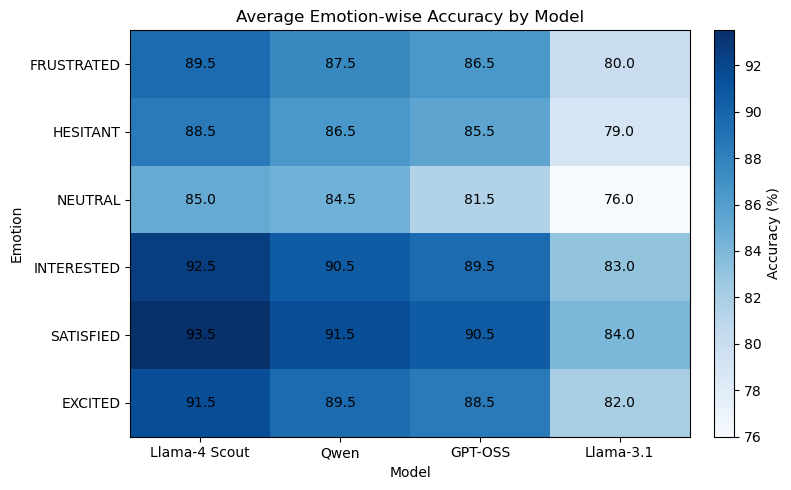

In [28]:
# Build a heatmap of average emotion accuracy by model
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(emotion_model_pivot.values * 100, cmap="Blues", aspect="auto")

ax.set_title("Average Emotion-wise Accuracy by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Emotion")
ax.set_xticks(range(len(emotion_model_pivot.columns)))
ax.set_xticklabels(emotion_model_pivot.columns)
ax.set_yticks(range(len(emotion_model_pivot.index)))
ax.set_yticklabels(emotion_model_pivot.index)

for i in range(emotion_model_pivot.shape[0]):
    for j in range(emotion_model_pivot.shape[1]):
        ax.text(j, i, f"{emotion_model_pivot.iloc[i, j] * 100:.1f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Accuracy (%)")
plt.tight_layout()
plt.show()

### Emotion-wise prompt comparison for each model

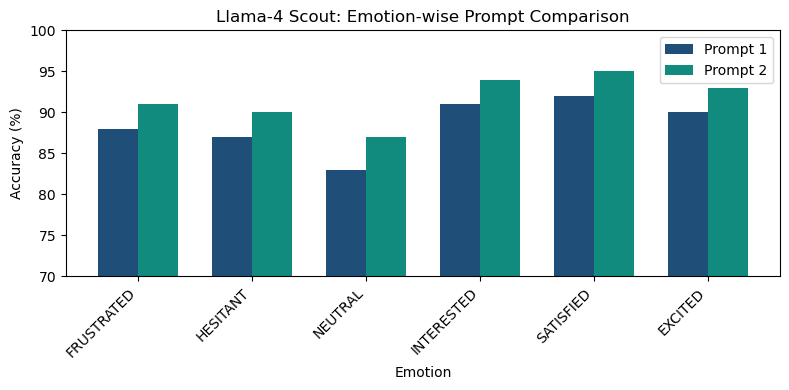

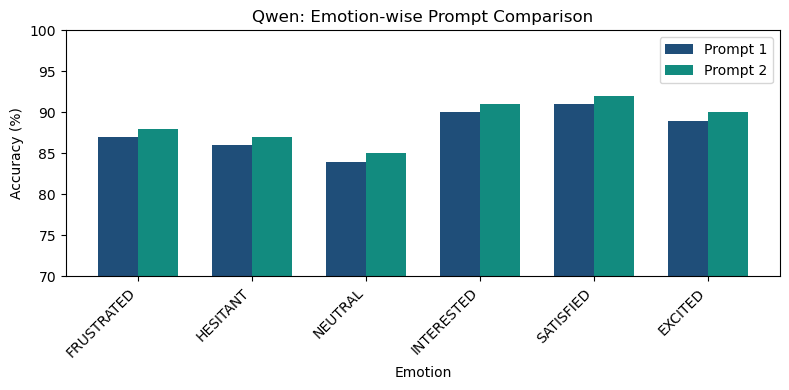

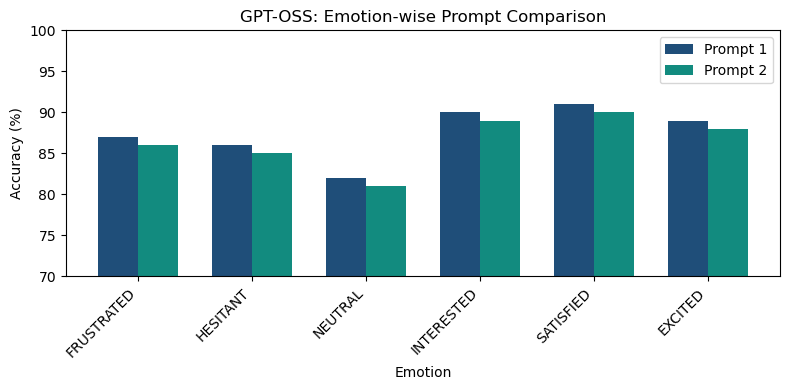

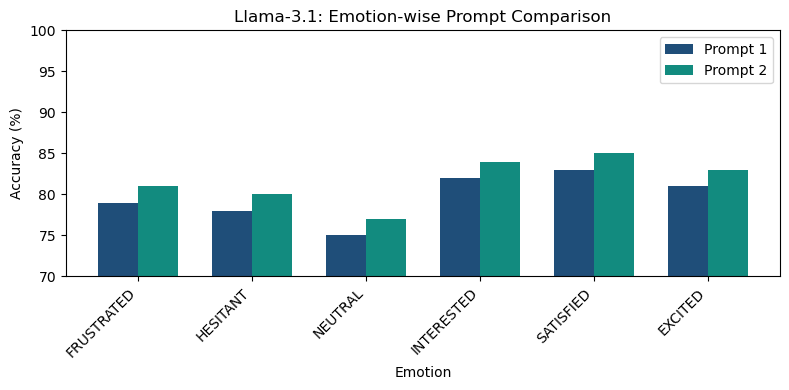

In [29]:
# Compare Prompt 1 and Prompt 2 for each model by emotion
for current_model in MODEL_ORDER:
    subset = class_df[class_df["model"] == current_model]
    if subset.empty:
        continue

    pivot_df = subset.pivot(index="emotion", columns="prompt", values="class_accuracy").loc[EMOTION_ORDER]

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(pivot_df.index))
    width = 0.35

    ax.bar(x - width / 2, pivot_df["PROMPT1"] * 100, width, color=PROMPT1_COLOR, label="Prompt 1")
    ax.bar(x + width / 2, pivot_df["PROMPT2"] * 100, width, color=PROMPT2_COLOR, label="Prompt 2")

    ax.set_title(f"{current_model}: Emotion-wise Prompt Comparison")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(70, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_df.index, rotation=45, ha="right")
    ax.legend()

    plt.tight_layout()
    plt.show()

### Summary tables

In [30]:
# Identify the best overall instance and the best model for each emotion
best_instance = overall_df.loc[overall_df["overall_accuracy"].idxmax()].copy()
best_instance["overall_accuracy_pct"] = best_instance["overall_accuracy"] * 100
display(best_instance.to_frame().T)

best_emotion_rows = (
    class_df.sort_values("class_accuracy", ascending=False)
    .groupby("emotion", observed=False)
    .head(1)
    .sort_values("emotion")
    .reset_index(drop=True)
)
display(best_emotion_rows)

,file_name,model_full,model,prompt,overall_accuracy,overall_accuracy_pct
1,meta-llama_llama-4-scout-17b-16e-instruct_2.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT2,0.92,92.0


,file_name,model_full,model,prompt,emotion,class_accuracy
0,meta-llama_llama-4-scout-17b-16e-instruct_2.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT2,FRUSTRATED,0.91
1,meta-llama_llama-4-scout-17b-16e-instruct_2.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT2,HESITANT,0.90
2,meta-llama_llama-4-scout-17b-16e-instruct_2.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT2,NEUTRAL,0.87
3,meta-llama_llama-4-scout-17b-16e-instruct_2.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT2,INTERESTED,0.94
4,meta-llama_llama-4-scout-17b-16e-instruct_2.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT2,SATISFIED,0.95
5,meta-llama_llama-4-scout-17b-16e-instruct_2.json,meta-llama_llama-4-scout-17b-16e-instruct,Llama-4 Scout,PROMPT2,EXCITED,0.93


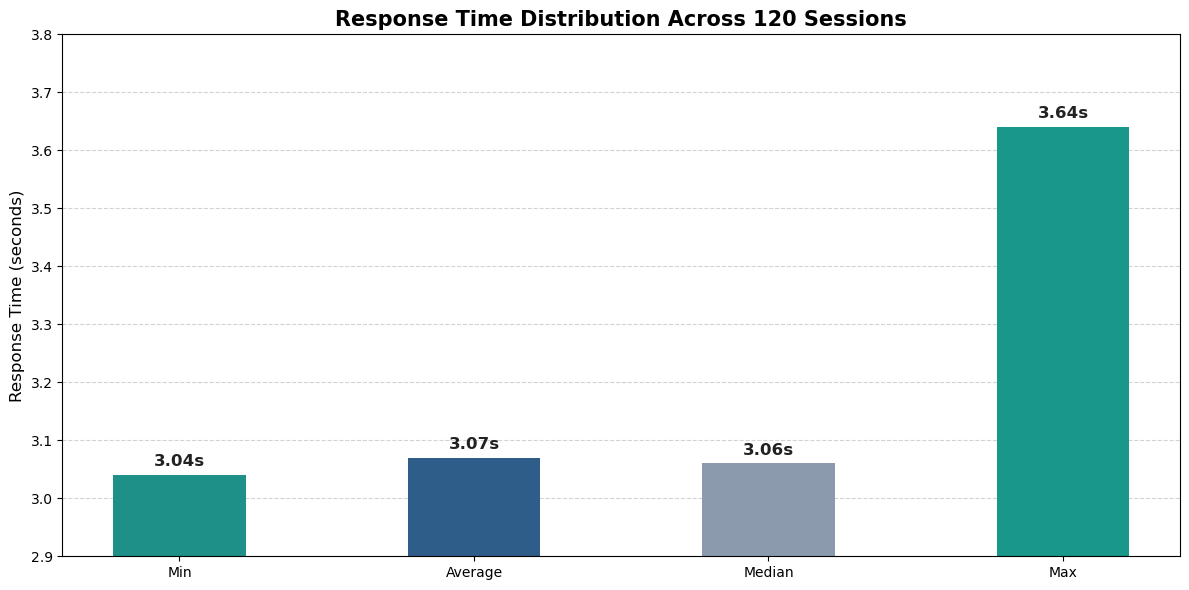

In [37]:
# Plot response time distribution across sessions
response_time_df = pd.DataFrame([
    {'metric': 'Min', 'seconds': 3.04},
    {'metric': 'Average', 'seconds': 3.07},
    {'metric': 'Median', 'seconds': 3.06},
    {'metric': 'Max', 'seconds': 3.64},
])

palette = ['#1f9087', '#2f5d8a', '#8b9bad', "#1a978b"]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(response_time_df['metric'], response_time_df['seconds'], color=palette, width=0.45)

ax.set_title('Response Time Distribution Across 120 Sessions', fontsize=15, weight='bold')
ax.set_ylabel('Response Time (seconds)', fontsize=12)
ax.set_ylim(2.9, 3.8)
ax.grid(axis='y', linestyle='--', linewidth=0.8, alpha=0.55)
ax.set_axisbelow(True)

for bar, value in zip(bars, response_time_df['seconds']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f'{value:.2f}s',
        ha='center',
        va='bottom',
        fontsize=12,
        weight='bold',
        color='#222222',
    )

plt.tight_layout()
plt.show()
